<a href="https://colab.research.google.com/github/izzat-ai/learning-ai/blob/main/data_visualization/matplotlib/practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ushbu sahifada matplotlib kutubxonasi amaliyot qilinadi . Datasetlar Sun'iy intellekt tomonidan yaratiladi.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# 2023 yil davomida bitta onlayn do'konning kunlik sotuvlari ma'lumotlari -> AI yordamida yaratildi
np.random.seed(42)

dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Asosiy trend + mavsumiylik + shovqin
trend = np.linspace(1000, 1800, len(dates))
seasonality = 300 * np.sin(2 * np.pi * dates.dayofyear / 365)
noise = np.random.normal(0, 100, len(dates))

daily_sales = trend + seasonality + noise
daily_sales = np.clip(daily_sales, 200, None)  # manfiy bo'lmasin

df_sales = pd.DataFrame({
    'date': dates,
    'daily_revenue': daily_sales.round(2)
})
df_sales

,date,daily_revenue
0,2023-01-01,1054.84
1,2023-01-02,998.70
2,2023-01-03,1084.65
3,2023-01-04,1179.54
4,2023-01-05,1011.17
...,...,...
360,2023-12-27,1822.50
361,2023-12-28,1931.19
362,2023-12-29,1774.40
363,2023-12-30,1832.81


In [3]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           365 non-null    datetime64[ns]
 1   daily_revenue  365 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.8 KB


In [4]:
df_sales.shape

(365, 2)

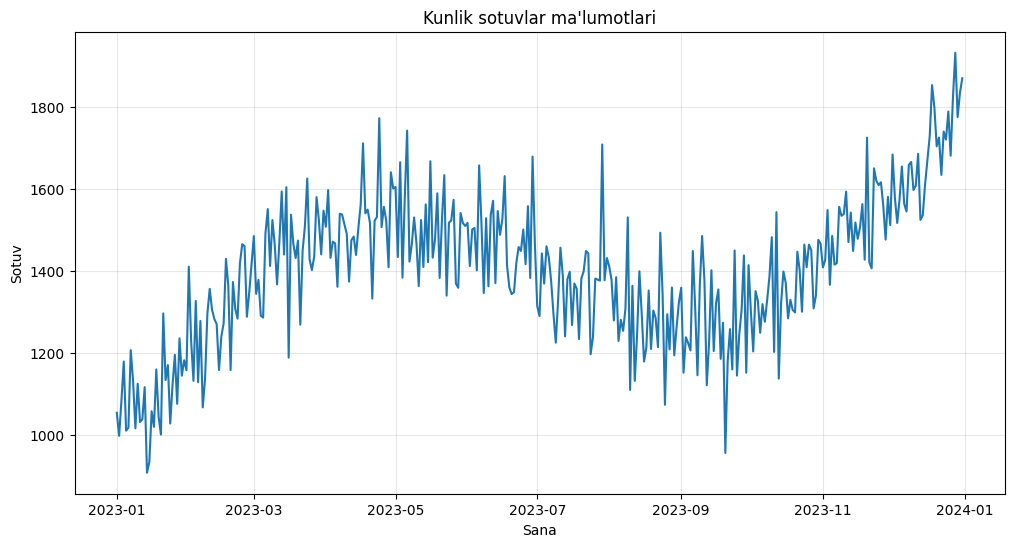

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(df_sales['date'], df_sales['daily_revenue'])

plt.title("Kunlik sotuvlar ma'lumotlari")
plt.xlabel("Sana")
plt.ylabel("Sotuv")

plt.grid(True, alpha=0.3)

plt.show()

- 2023-yil boshida sotuvlar 1000 ni tashkil qilgan bo'lsa , yil ohiri va 2024-yil boshiga kelib bu ko'rsatkich 1800 dan ham yuqorilagan . Bundan umumiy tendensiya o'sib borganini anglashimiz mumkin .
- Sotuvlar Bahor va Kuz oylarida yuqorilagan bo'lsa , Kuz va Qish oylarida sezirarli kamaygan .
- Kuz va Qishdagi sezirarli pasayishlarini oldini olish chora-tadbirlarini ko'rish kerak bo'ladi .

In [12]:
np.random.seed(7)

# Uchta mahsulot toifasining 2023 yildagi oylik sotuvlari (dona hisobida)
months = pd.date_range(start='2023-01-01', end='2023-12-01', freq='MS')

electronics = np.array([1200, 1350, 1100, 1450, 1600, 1750,
                         1900, 2100, 1800, 2300, 3200, 4100])

clothing = np.array([800, 750, 900, 1100, 1300, 1250,
                      1000, 950, 1150, 1400, 2200, 2800])

furniture = np.array([400, 420, 380, 500, 550, 600,
                       580, 620, 610, 700, 950, 1300])

df_monthly = pd.DataFrame({
    'month': months,
    'electronics': electronics,
    'clothing': clothing,
    'furniture': furniture
})
df_monthly.head()

,month,electronics,clothing,furniture
0,2023-01-01,1200,800,400
1,2023-02-01,1350,750,420
2,2023-03-01,1100,900,380
3,2023-04-01,1450,1100,500
4,2023-05-01,1600,1300,550


In [13]:
df_monthly.shape

(12, 4)

In [14]:
df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   month        12 non-null     datetime64[ns]
 1   electronics  12 non-null     int64         
 2   clothing     12 non-null     int64         
 3   furniture    12 non-null     int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 516.0 bytes


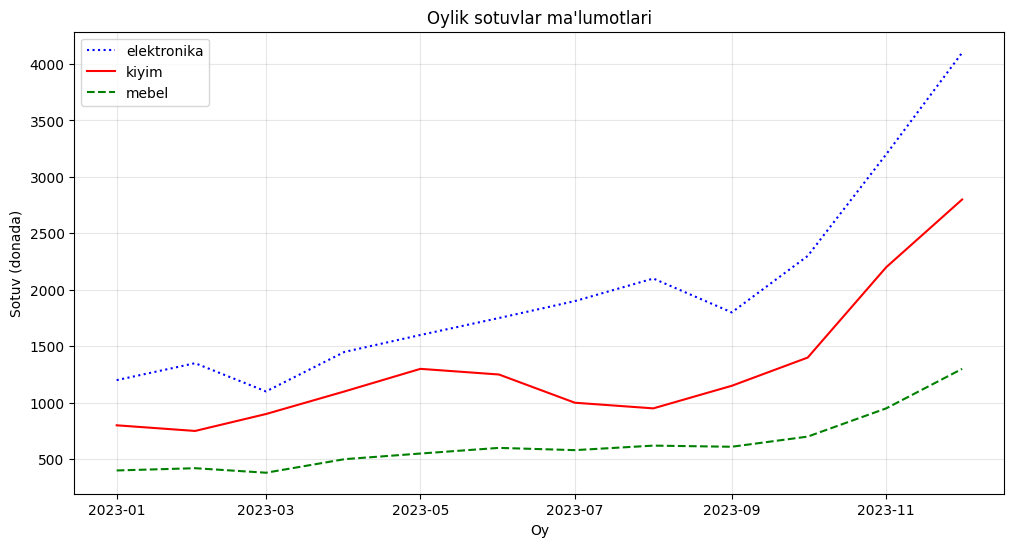

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(df_monthly['month'], df_monthly['electronics'], label='elektronika', color='blue', linestyle=':')
plt.plot(df_monthly['month'], df_monthly['clothing'], label='kiyim', color='red')
plt.plot(df_monthly['month'], df_monthly['furniture'], label='mebel', color='green', linestyle='--')

plt.title("Oylik sotuvlar ma'lumotlari")
plt.xlabel("Oy")
plt.ylabel("Sotuv (donada)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

- Elektronika yil davomida eng yuqori ko'rsatgichga ega bo'lgan , Mebellar esa doimiy past ko'rsatgichni qayd etgan .
- Barcha mahsulotlar bo'yicha Kuz oylarini ohiri va Qish oylarida yuqori o'sish kuzatilgan
- Elektronika va Kiyim-kechaklarda avgust va sentabr oylarida bir xil pasayishlar bo'lgan
- Keyingi yilda - elektronika va kiyimga katta e'tibor berish va yoz , kuz oylarida chegirmalar qilish tavsiya qilinadi .

In [22]:
np.random.seed(21)

# 200 ta uy-joyning maydoni va narxi

df_housing = pd.DataFrame({
    'area_sqm': np.random.normal(120, 40, 200).clip(30, 300).round(1),
    'price_usd': None  # vaqtinchalik, pastda hisoblanadi
})

df_housing['price_usd'] = (df_housing['area_sqm'] * 850 +
                             np.random.normal(0, 8000, 200)).clip(15000, None).round(0)

df_housing.head()

,area_sqm,price_usd
0,117.9,120773.0
1,115.6,92867.0
2,161.7,134587.0
3,69.7,47631.0
4,149.8,132097.0


In [23]:
df_housing.shape

(200, 2)

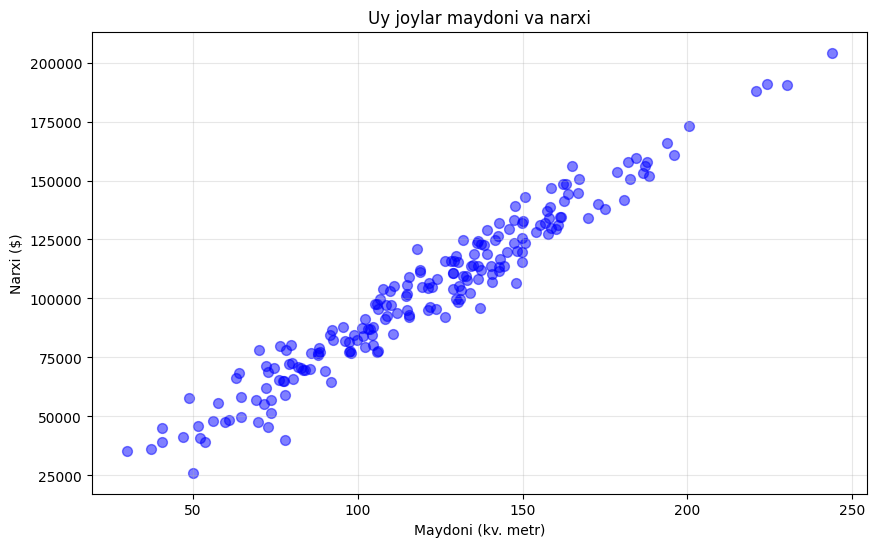

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(df_housing['area_sqm'], df_housing['price_usd'], color='blue', alpha=0.5, s=50)

plt.title("Uy joylar maydoni va narxi")
plt.xlabel("Maydoni (kv. metr)")
plt.ylabel("Narxi ($)")

plt.grid(True, alpha=0.3)

plt.show()

- Ushbu grafikdan uy-joylarning maydoni va narxi o'rtasidagi bog'liqlik qanchalik yaxshi yoki yomon ekanini ko'rishimiz mumkin
- Uy maydoni oshgani sari , uning narxi ham shunga mos ravishda oshib bormoqda . Bu ijobiy bog'liqlik borligini bildiradi
- Aksar uylar 80 kv metr va 170 kv metr hamda narxlari esa 65000 dan 150000 gacha bo'lgan oraliqda to'plangan
- Grafik bir necha anomal qiymatlarni ham ko'rsatmoqda . Hususan , 50 kv metr uy juda arzonligi va 200 kv metrdan ko'p hajmli uylar juda qimmatligi shubhali
- Demak , uy-joylarning narxini belgilashda ularning kv metrlariga bog'lash maqsadga muvofiq bo'ladi

In [29]:
np.random.seed(33)

# 250 ta xodim ma'lumotlari

df_employees = pd.DataFrame({
    'experience_years': np.random.uniform(0, 20, 250).round(1),
    'department': np.random.choice(['Sales', 'Engineering', 'Marketing'], 250, p=[0.4, 0.35, 0.25])
})

df_employees['annual_salary'] = (
    np.where(df_employees['department'] == 'Engineering', 45000,
    np.where(df_employees['department'] == 'Sales', 35000, 32000))
    + df_employees['experience_years'] * 2200
    + np.random.normal(0, 4000, 250)
).round(0)

df_employees.head()

,experience_years,department,annual_salary
0,5.0,Sales,47253.0
1,9.0,Engineering,72833.0
2,8.2,Marketing,53034.0
3,5.2,Sales,43986.0
4,17.4,Sales,65567.0


In [31]:
#plt.scatter(df_employees['experience_years'], df_employees['annual_salary'])
#plt.show()